# Análise de Resultados - PUMA FL
Este notebook processa as múltiplas simulações (runs) geradas pelo servidor e plota as curvas de performance comparando diferentes estratégias, exibindo o intervalo de confiança (desvio padrão).

In [57]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Configuração de estilo para gráficos nível artigo acadêmico
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 14,
    'lines.linewidth': 2.5
})

# Caminho padrão para a pasta de resultados
RESULTS_DIR = "../results/"

In [58]:
def load_strategy_results(dataset, strategy, paca=12, algo="FedAVG", prune="prune"):
    """
    Busca os arquivos h5 gerados pelo servidor e calcula média e desvio padrão.
    """
    pattern = os.path.join(RESULTS_DIR, f"{dataset}_{strategy}_paca{paca}_{prune}_{algo}_run*.h5")
    files = glob.glob(pattern)
    
    if not files:
        print(f"⚠️ Nenhum arquivo encontrado para: {pattern}")
        return None
        
    print(f"✅ Encontrados {len(files)} arquivos para o padrão: {dataset}_{strategy}_paca{paca}_{prune}_{algo}")
    
    acc_runs, loss_runs, mb_runs, mb_bruto_runs, time_runs, params_runs, size_runs = [], [], [], [], [], [], []
    
    for f in files:
        with h5py.File(f, 'r') as hf:
            acc_runs.append(np.array(hf['rs_test_acc']))
            loss_runs.append(np.array(hf['rs_train_loss']))
            mb_runs.append(np.array(hf['sended_model_Mb']))
            mb_bruto_runs.append(np.array(hf['Sended_without_quant']))
            time_runs.append(np.array(hf['Round_time']))
            
            # Condicional para retrocompatibilidade com simulações antigas (Parâmetros)
            if 'Trainable_params' in hf:
                params_runs.append(np.array(hf['Trainable_params']))
            else:
                params_runs.append(np.zeros_like(np.array(hf['Round_time'])))
                
            # Condicional para retrocompatibilidade com tamanho do modelo por rodada
            if 'Model_size_per_round_Mb' in hf:
                size_runs.append(np.array(hf['Model_size_per_round_Mb']))
            else:
                size_runs.append(np.zeros_like(np.array(hf['Round_time'])))
            
    return {
        'acc_mean': np.mean(acc_runs, axis=0), 'acc_std': np.std(acc_runs, axis=0),
        'loss_mean': np.mean(loss_runs, axis=0), 'loss_std': np.std(loss_runs, axis=0),
        'mb_mean': np.mean(mb_runs, axis=0), 'mb_std': np.std(mb_runs, axis=0),
        'mb_bruto_mean': np.mean(mb_bruto_runs, axis=0), 'mb_bruto_std': np.std(mb_bruto_runs, axis=0),
        'time_mean': np.mean(time_runs, axis=0), 'time_std': np.std(time_runs, axis=0),
        'params_mean': np.mean(params_runs, axis=0), 'params_std': np.std(params_runs, axis=0),
        'size_mb_mean': np.mean(size_runs, axis=0), 'size_mb_std': np.std(size_runs, axis=0),
    }

In [59]:
DATASET = "OxfordPets"

print("Carregando resultados do Servidor...")

dados_sora_p12 = load_strategy_results(DATASET, "sora_with_schedule", paca=12, prune="prune")
dados_sora_p9 = load_strategy_results(DATASET, "sora_with_schedule", paca=9, prune="prune")

dados_lora_p12 = load_strategy_results(DATASET, "lora", paca=12, prune="prune")
dados_lora_p6 = load_strategy_results(DATASET, "lora", paca=6, prune="prune")

# Lista de configurações para iterar nos gráficos (deixa o código limpo e escalável)
# Formato: (Label, Dados, Cor, Marcador, Estilo de linha)
configs = [
    ('SoRA (PaCA=Null)', dados_sora_p12, '#d62728', 's', '-'),   # Vermelho
    ('SoRA (PaCA=9)', dados_sora_p9, '#ff7f0e', '^', '-'),   # Laranja
    ('LoRA (PaCA=Null)', dados_lora_p12, '#1f77b4', 'o', '--'),  # Azul
    ('LoRA (PaCA=6)', dados_lora_p6, '#2ca02c', 'd', '--')   # Verde
]

Carregando resultados do Servidor...
✅ Encontrados 1 arquivos para o padrão: OxfordPets_sora_with_schedule_paca12_prune_FedAVG
✅ Encontrados 1 arquivos para o padrão: OxfordPets_sora_with_schedule_paca9_prune_FedAVG
✅ Encontrados 1 arquivos para o padrão: OxfordPets_lora_paca12_prune_FedAVG
⚠️ Nenhum arquivo encontrado para: ../results/OxfordPets_lora_paca6_prune_FedAVG_run*.h5


### 1. Desempenho do Modelo (Acurácia Global)

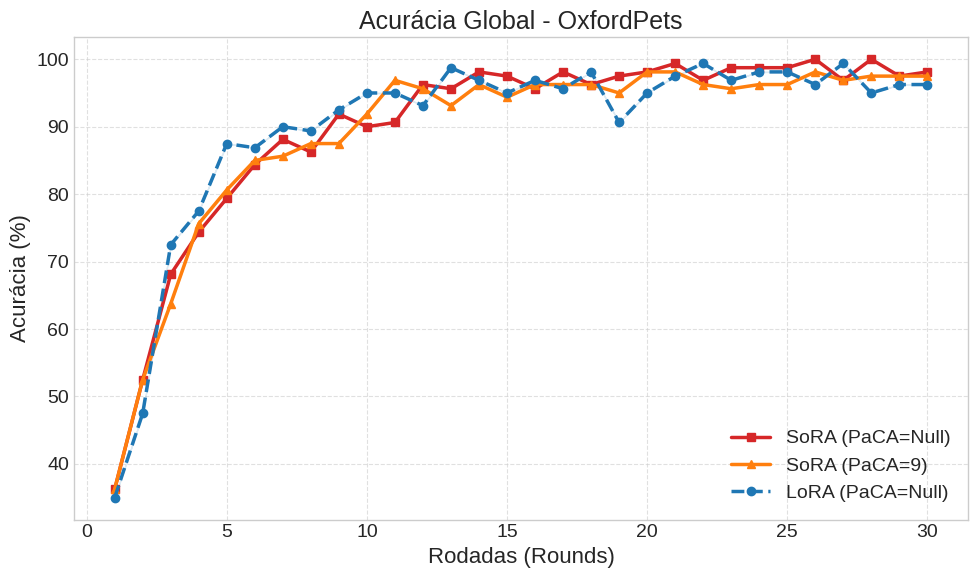

In [60]:
plt.figure(figsize=(10, 6))

plotou_algo = False
for label, dados, color, marker, ls in configs:
    if isinstance(dados, dict):
        eixo = range(1, len(dados['acc_mean']) + 1)
        plt.plot(eixo, dados['acc_mean'], label=label, color=color, linestyle=ls, marker=marker)
        plt.fill_between(eixo, 
                         dados['acc_mean'] - dados['acc_std'], 
                         dados['acc_mean'] + dados['acc_std'], color=color, alpha=0.15)
        plotou_algo = True

if plotou_algo:
    plt.title(f"Acurácia Global - {DATASET}")
    plt.xlabel("Rodadas (Rounds)")
    plt.ylabel("Acurácia (%)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Nenhum dado encontrado para gerar o gráfico de Acurácia.")

### 2. Custo de Comunicação Acumulado (Megabytes)

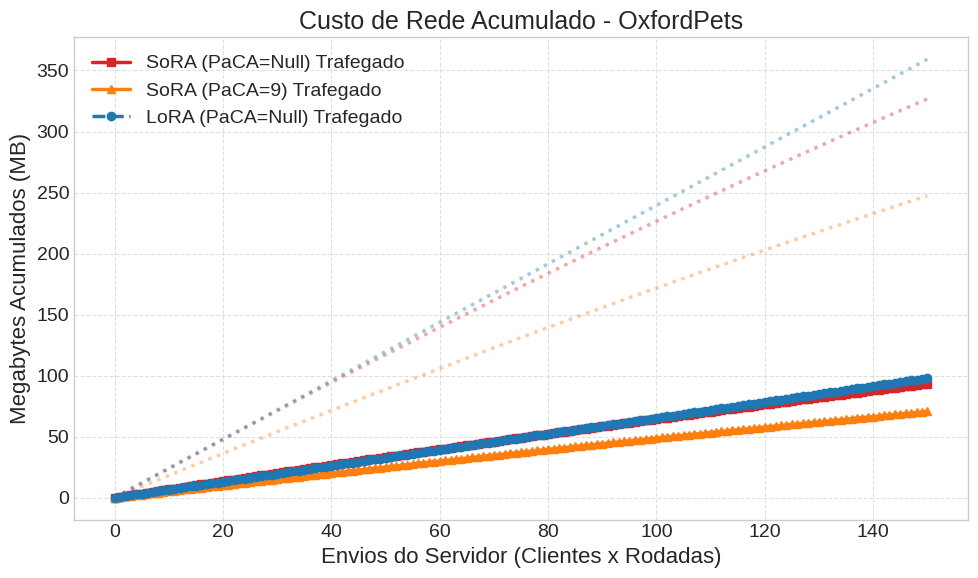

In [61]:
plt.figure(figsize=(10, 6))

plotou_algo = False
for label, dados, color, marker, ls in configs:
    if isinstance(dados, dict):
        eixo = range(len(dados['mb_mean']))
        
        # Linha pontilhada apagada mostrando o tamanho bruto daquela configuração
        plt.plot(eixo, dados['mb_bruto_mean'], color=color, linestyle=':', alpha=0.4)
        
        # Linha principal com quantização/SoRA
        plt.plot(eixo, dados['mb_mean'], label=f"{label} Trafegado", color=color, linestyle=ls, marker=marker)
        plt.fill_between(eixo, 
                         dados['mb_mean'] - dados['mb_std'], 
                         dados['mb_mean'] + dados['mb_std'], color=color, alpha=0.15)
        plotou_algo = True

if plotou_algo:
    plt.title(f"Custo de Rede Acumulado - {DATASET}")
    plt.xlabel("Envios do Servidor (Clientes x Rodadas)")
    plt.ylabel("Megabytes Acumulados (MB)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Nenhum dado encontrado para gerar o gráfico de Comunicação.")

### 3. Latência de Treinamento (Tempo)

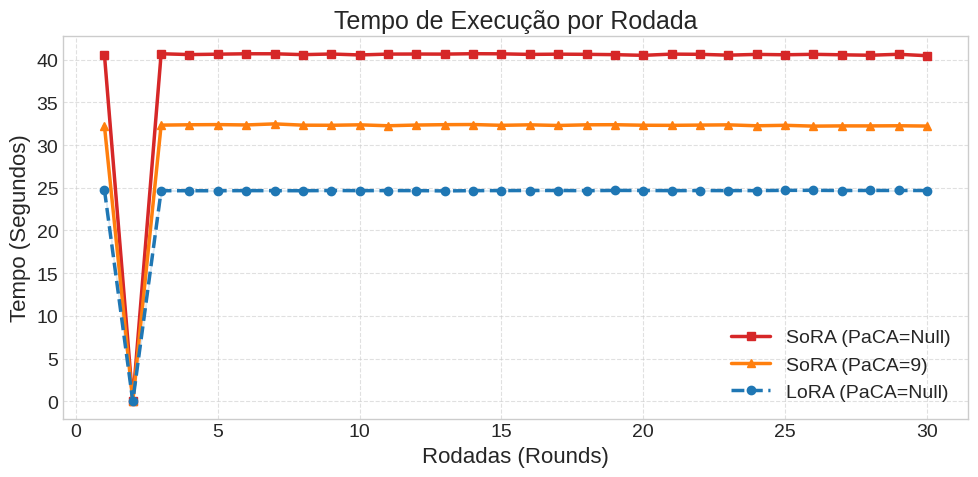

In [62]:
plt.figure(figsize=(10, 5))

plotou_algo = False
for label, dados, color, marker, ls in configs:
    if isinstance(dados, dict):
        eixo = range(1, len(dados['time_mean']) + 1)
        plt.plot(eixo, dados['time_mean'], label=label, color=color, linestyle=ls, marker=marker)
        plt.fill_between(eixo, 
                         dados['time_mean'] - dados['time_std'], 
                         dados['time_mean'] + dados['time_std'], color=color, alpha=0.15)
        plotou_algo = True

if plotou_algo:
    plt.title("Tempo de Execução por Rodada")
    plt.xlabel("Rodadas (Rounds)")
    plt.ylabel("Tempo (Segundos)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Nenhum dado encontrado para gerar o gráfico de Latência.")

### 4. Tamanho do Modelo por Rodada e Evolução de Parâmetros

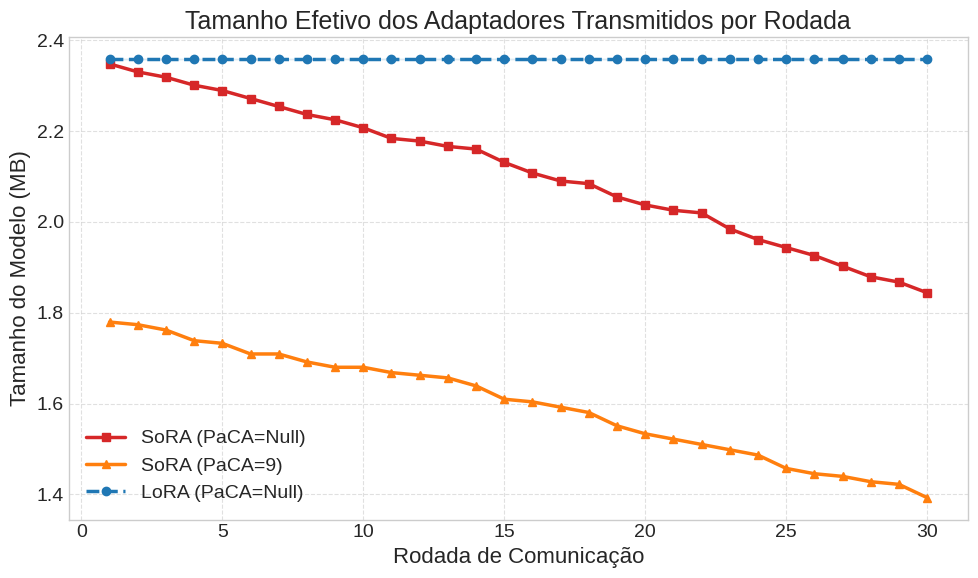

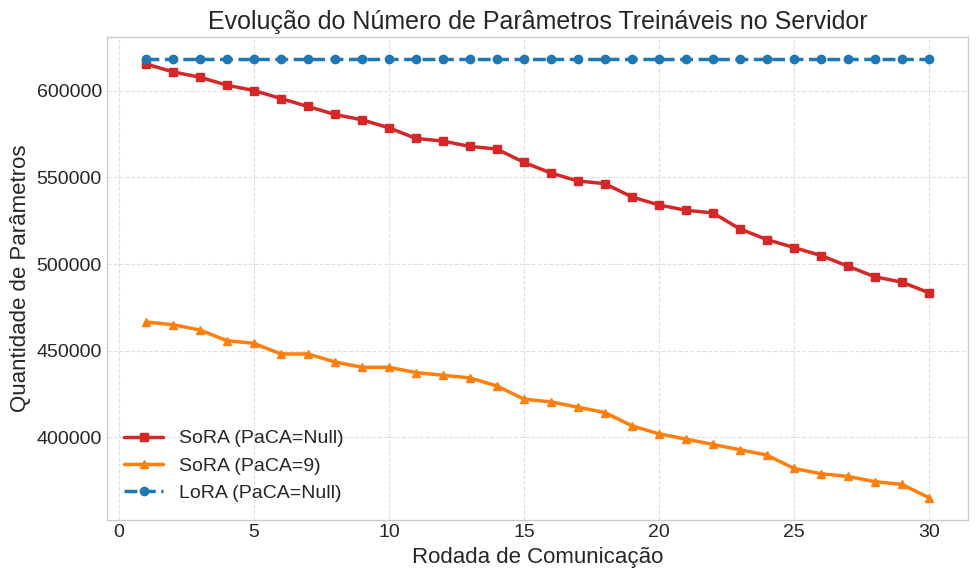

In [63]:
# --------------------------------------------------------------------------
# Gráfico 4.1: Tamanho Efetivo dos Adaptadores por Rodada (em MB)
# --------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plotou_algo = False

for label, dados, color, marker, ls in configs:
    if isinstance(dados, dict) and 'size_mb_mean' in dados:
        eixo = range(1, len(dados['size_mb_mean']) + 1)
        plt.plot(eixo, dados['size_mb_mean'], label=label, color=color, linestyle=ls, marker=marker)
        plt.fill_between(eixo, 
                         dados['size_mb_mean'] - dados['size_mb_std'], 
                         dados['size_mb_mean'] + dados['size_mb_std'], color=color, alpha=0.15)
        plotou_algo = True

if plotou_algo:
    plt.title("Tamanho Efetivo dos Adaptadores Transmitidos por Rodada")
    plt.xlabel("Rodada de Comunicação")
    plt.ylabel("Tamanho do Modelo (MB)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Nenhum dado de tamanho de modelo encontrado.")

# --------------------------------------------------------------------------
# Gráfico 4.2: Evolução do Número de Parâmetros Treináveis
# --------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plotou_algo = False

for label, dados, color, marker, ls in configs:
    if isinstance(dados, dict) and 'params_mean' in dados:
        eixo = range(1, len(dados['params_mean']) + 1)
        plt.plot(eixo, dados['params_mean'], label=label, color=color, linestyle=ls, marker=marker)
        plotou_algo = True

if plotou_algo:
    plt.title("Evolução do Número de Parâmetros Treináveis no Servidor")
    plt.xlabel("Rodada de Comunicação")
    plt.ylabel("Quantidade de Parâmetros")
    plt.ticklabel_format(style='plain', axis='y') 
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Nenhum dado de parâmetro encontrado.")